# L2: Build Customized RAG

In [8]:
import os
import warnings
from dotenv import load_dotenv

warnings.filterwarnings("ignore")
_ = load_dotenv()

In [5]:
from haystack import Pipeline
from haystack.utils.auth import Secret
from haystack.components.builders import PromptBuilder
from haystack.components.converters import HTMLToDocument
from haystack.components.fetchers import LinkContentFetcher
from haystack.components.generators import OpenAIGenerator
from haystack.components.retrievers.in_memory import InMemoryEmbeddingRetriever
from haystack.components.writers import DocumentWriter
from haystack.document_stores.in_memory import InMemoryDocumentStore

from haystack_integrations.components.embedders.cohere import CohereDocumentEmbedder, CohereTextEmbedder

## Indexing Documents

In [9]:
document_store = InMemoryDocumentStore()

fetcher = LinkContentFetcher()
converter = HTMLToDocument()
embedder = CohereDocumentEmbedder(model="embed-english-v3.0", api_base_url=os.getenv("CO_API_URL"))
writer = DocumentWriter(document_store=document_store)

indexing = Pipeline()
indexing.add_component("fetcher", fetcher)
indexing.add_component("converter", converter)
indexing.add_component("embedder", embedder)
indexing.add_component("writer", writer)

indexing.connect("fetcher.streams", "converter.sources")
indexing.connect("converter", "embedder")
indexing.connect("embedder", "writer")

🚅 Components
  - fetcher: LinkContentFetcher
  - converter: HTMLToDocument
  - embedder: CohereDocumentEmbedder
  - writer: DocumentWriter
🛤️ Connections
  - fetcher.streams -> converter.sources (list[ByteStream])
  - converter.documents -> embedder.documents (list[Document])
  - embedder.documents -> writer.documents (list[Document])

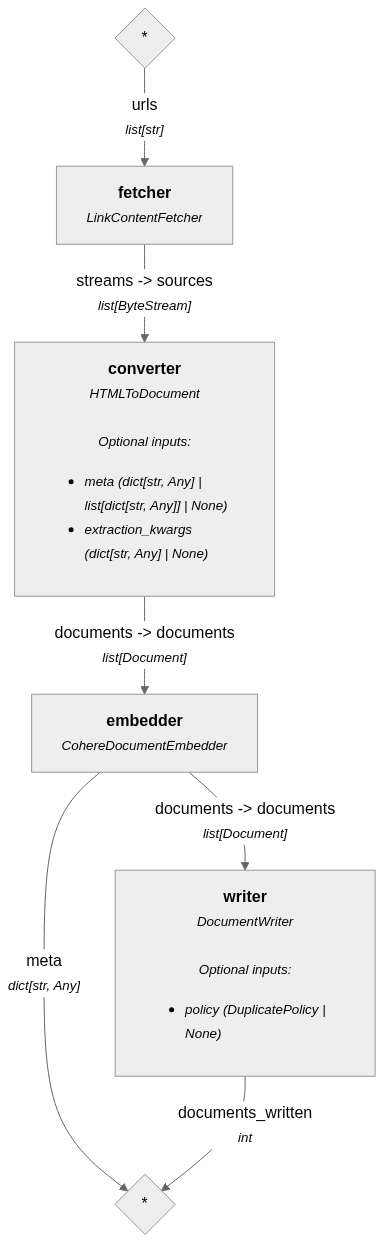

In [10]:
indexing.show()

In [11]:
indexing.run(
    {
        "fetcher": {
            "urls": [
                "https://haystack.deepset.ai/integrations/cohere",
                "https://haystack.deepset.ai/integrations/anthropic",
                "https://haystack.deepset.ai/integrations/jina",
                "https://haystack.deepset.ai/integrations/nvidia"
            ]
        }
    }
)

Calculating embeddings: 100%|██████████| 1/1 [00:00<00:00,  1.25it/s]


{'embedder': {'meta': {'api_version': {'version': '2',
    'is_deprecated': None,
    'is_experimental': None},
   'billed_units': {'images': None,
    'input_tokens': 2032.0,
    'output_tokens': None,
    'search_units': None,
    'classifications': None},
   'tokens': None,
   'cached_tokens': None,
   'warnings': None}},
 'writer': {'documents_written': 4}}

In [12]:
document_store.filter_documents()[0]

Document(id=da82644777144c9b29f2d504f2cbd51562b3d48b34f4097499f49c2618b7c44b, content: 'Integration: Cohere
Use Cohere models with Haystack
Table of Contents
Overview
You can use Cohere Mo...', meta: {'content_type': 'text/html', 'url': 'https://haystack.deepset.ai/integrations/cohere'}, embedding: vector of size 1024)

## Retrieval Augmented Generation

### 1. Decide on the Prompt

Augment the prompt with the contents of these documents using the **PromptBuilder**. This component uses Jinja templating.

In [13]:
prompt = """
Answer the question based on the provided context.
Context:
{% for doc in documents %}
    {{ doc.content }}
{% endfor %}
Question: {{ query }}
"""

### 2. Build the Pipeline

In [14]:
query_embedder = CohereTextEmbedder(model="embed-english-v3.0", api_base_url=os.getenv("COHERE_API_URL"))
retriever = InMemoryEmbeddingRetriever(document_store=document_store)
prompt_builder = PromptBuilder(template=prompt)
generator = OpenAIGenerator()

rag = Pipeline()
rag.add_component("query_embedder", query_embedder)
rag.add_component("retriever", retriever)
rag.add_component("prompt", prompt_builder)
rag.add_component("generator", generator)

rag.connect("query_embedder.embedding", "retriever.query_embedding")
rag.connect("retriever.documents", "prompt.documents")
rag.connect("prompt", "generator")

PromptBuilder has 2 prompt variables, but `required_variables` is not set. By default, all prompt variables are treated as optional, which may lead to unintended behavior in multi-branch pipelines. To avoid unexpected execution, ensure that variables intended to be required are explicitly set in `required_variables`.


🚅 Components
  - query_embedder: CohereTextEmbedder
  - retriever: InMemoryEmbeddingRetriever
  - prompt: PromptBuilder
  - generator: OpenAIGenerator
🛤️ Connections
  - query_embedder.embedding -> retriever.query_embedding (list[float])
  - retriever.documents -> prompt.documents (list[Document])
  - prompt.prompt -> generator.prompt (str)

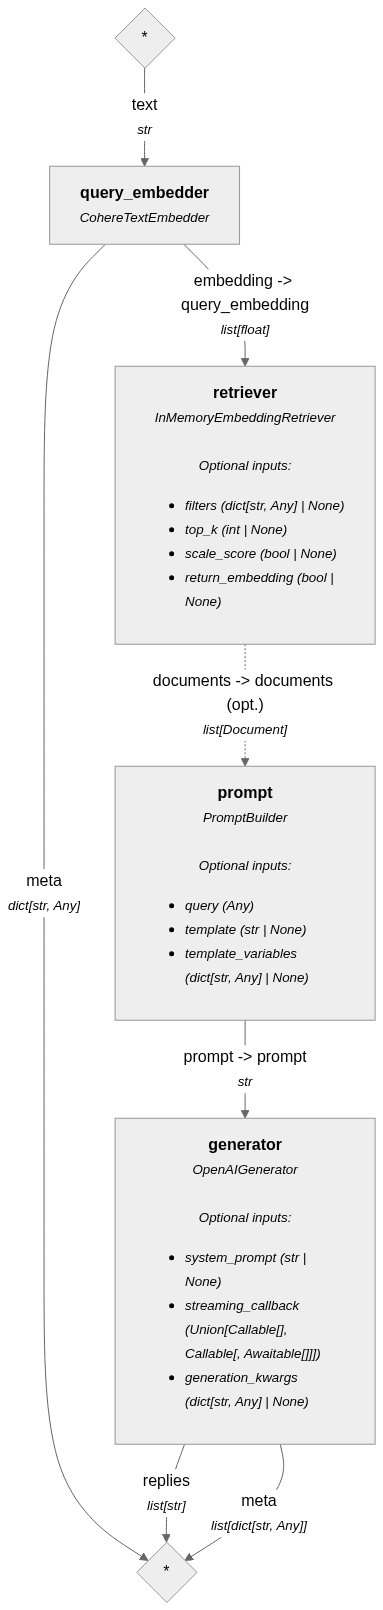

In [15]:
rag.show()

In [16]:
question = "How can I use Cohere with Haystack?"

result = rag.run(
    {
        "query_embedder": {
            "text": question
        },
        "retriever": {
            "top_k": 1
        },
        "prompt": {
            "query": question
        }
    }
)

print(result["generator"]["replies"][0])

Short answer
- Install the integration: pip install cohere-haystack
- Set your Cohere API key in COHERE_API_KEY or CO_API_KEY
- Use the provided Haystack components to add Cohere functionality:
  - Embedders: CohereTextEmbedder (queries), CohereDocumentEmbedder (text docs), CohereDocumentImageEmbedder (image docs)
  - Generators: CohereGenerator ( /generate models), CohereChatGenerator ( /chat models)
  - Ranker: CohereRanker ( /ranker models)

How to use (high-level)
1. Indexing (create embeddings)
   - Create a document store (e.g., InMemoryDocumentStore)
   - Add CohereDocumentEmbedder or CohereDocumentImageEmbedder to a Pipeline
   - Connect to a DocumentWriter to write embedded docs into the store
   - Example components: CohereDocumentEmbedder(model="embed-multilingual-v3.0")

2. Retrieval + generation (RAG / QA)
   - Use CohereTextEmbedder for query embeddings
   - Use a retriever (e.g., InMemoryEmbeddingRetriever) to find candidates
   - Build prompts with PromptBuilder or Chat

### 3. customize The Behaviour

In [17]:
prompt = """
You will be provided some context, followed by the URL that this context comes from.
Answer the question based on the context, and reference the URL from which your answer 
is generated.
Your answer should be in {{ language }}.
Context:
{% for doc in documents %}
    {{ doc.content }}
    URL: {{ doc.meta['url']}}
{% endfor %}
Question: {{ query }}
Answer:
"""

In [18]:
query_embedder = CohereTextEmbedder(
    model="embed-english-v3.0",
    api_base_url=os.getenv("COHERE_API_URL")
)
retriever = InMemoryEmbeddingRetriever(document_store=document_store)
prompt_builder = PromptBuilder(template=prompt)
generator = OpenAIGenerator(model="gpt-3.5-turbo")

rag = Pipeline()
rag.add_component("query_embedder", query_embedder)
rag.add_component("retriever", retriever)
rag.add_component("prompt", prompt_builder)
rag.add_component("generator", generator)

rag.connect("query_embedder.embedding", "retriever.query_embedding")
rag.connect("retriever.documents", "prompt.documents")
rag.connect("prompt", "generator")

PromptBuilder has 3 prompt variables, but `required_variables` is not set. By default, all prompt variables are treated as optional, which may lead to unintended behavior in multi-branch pipelines. To avoid unexpected execution, ensure that variables intended to be required are explicitly set in `required_variables`.


🚅 Components
  - query_embedder: CohereTextEmbedder
  - retriever: InMemoryEmbeddingRetriever
  - prompt: PromptBuilder
  - generator: OpenAIGenerator
🛤️ Connections
  - query_embedder.embedding -> retriever.query_embedding (list[float])
  - retriever.documents -> prompt.documents (list[Document])
  - prompt.prompt -> generator.prompt (str)

In [19]:
question = "How can I use Cohere with Haystack?"

result = rag.run(
    {
        "query_embedder": {
            "text": question
        },
        "retriever": {
            "top_k": 1
        },
        "prompt": {
            "query": question,
            "language": "French"
        }
    }
)

print(result["generator"]["replies"][0])

Vous pouvez utiliser les modèles Cohere dans vos pipelines Haystack en utilisant les générateurs et les incrusteurs. Pour ce faire, vous pouvez suivre les instructions fournies dans la documentation à l'URL suivante : https://haystack.deepset.ai/integrations/cohere.
